In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("kc_house_data.csv")

In [3]:
df=df.drop('id',axis=1)

In [4]:
df['date']=pd.to_datetime(df['date'])

In [5]:
df['year']=df['date'].apply(lambda date:date.year)

In [6]:
df['month']=df['date'].apply(lambda date:date.month)

In [7]:
df=df.drop(['date','zipcode'],axis=1)

In [8]:
df.isnull().sum()

price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
year             0
month            0
dtype: int64

In [9]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
price,21597.0,540296.573506,367368.140101,78000.0000,322000.0000,450000.0000,645000.000,7.700000e+06
bedrooms,21597.0,3.373200,0.926299,1.0000,3.0000,3.0000,4.000,3.300000e+01
bathrooms,21597.0,2.115826,0.768984,0.5000,1.7500,2.2500,2.500,8.000000e+00
sqft_living,21597.0,2080.321850,918.106125,370.0000,1430.0000,1910.0000,2550.000,1.354000e+04
sqft_lot,21597.0,15099.408760,41412.636876,520.0000,5040.0000,7618.0000,10685.000,1.651359e+06
floors,21597.0,1.494096,0.539683,1.0000,1.0000,1.5000,2.000,3.500000e+00
waterfront,21597.0,0.007547,0.086549,0.0000,0.0000,0.0000,0.000,1.000000e+00
view,21597.0,0.234292,0.766390,0.0000,0.0000,0.0000,0.000,4.000000e+00
condition,21597.0,3.409825,0.650546,1.0000,3.0000,3.0000,4.000,5.000000e+00
grade,21597.0,7.657915,1.173200,3.0000,7.0000,7.0000,8.000,1.300000e+01


<Figure size 2000x1200 with 0 Axes>

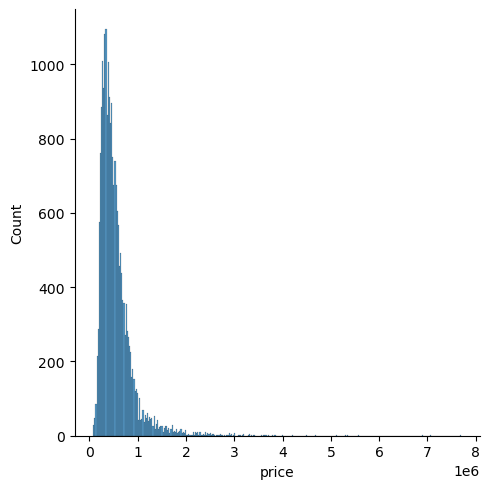

In [10]:
plt.figure(figsize=(20,12))
sns.displot(df['price'])

<Axes: xlabel='bedrooms', ylabel='count'>

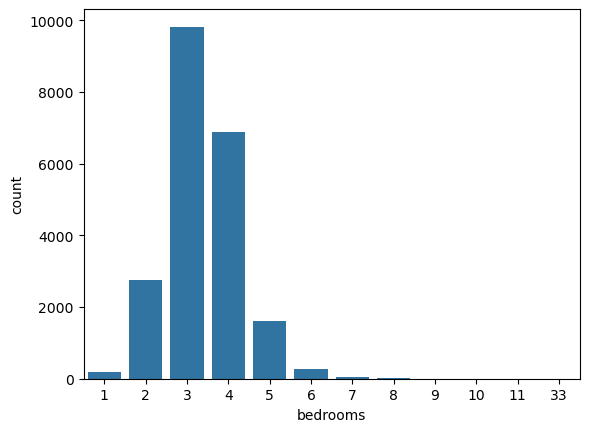

In [15]:
sns.countplot(data=df,x='bedrooms')

In [11]:
df.corr()['price'].sort_values()

month           -0.009928
year             0.003727
long             0.022036
condition        0.036056
yr_built         0.053953
sqft_lot15       0.082845
sqft_lot         0.089876
yr_renovated     0.126424
floors           0.256804
waterfront       0.266398
lat              0.306692
bedrooms         0.308787
sqft_basement    0.323799
view             0.397370
bathrooms        0.525906
sqft_living15    0.585241
sqft_above       0.605368
grade            0.667951
sqft_living      0.701917
price            1.000000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='sqft_living'>

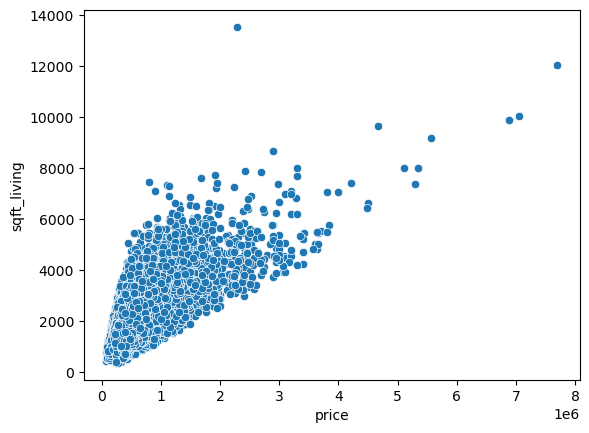

In [12]:
sns.scatterplot(x='price',y='sqft_living',data=df)

<Axes: xlabel='bedrooms', ylabel='price'>

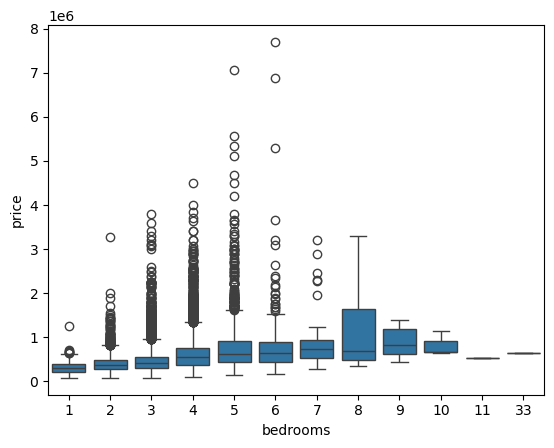

In [16]:
sns.boxplot(x='bedrooms',y='price',data=df)

<Axes: xlabel='price', ylabel='long'>

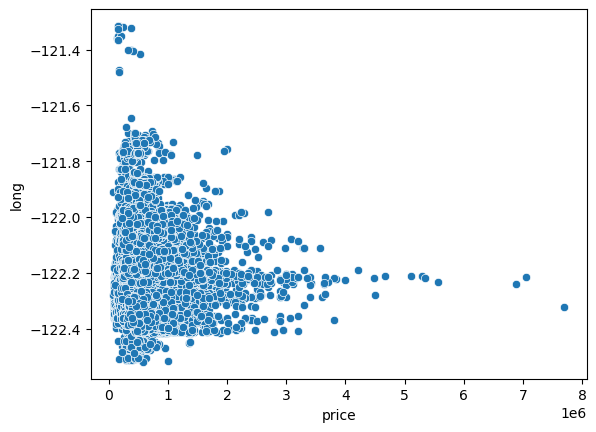

In [17]:
sns.scatterplot(x='price',y='long',data=df)

<Axes: xlabel='price', ylabel='lat'>

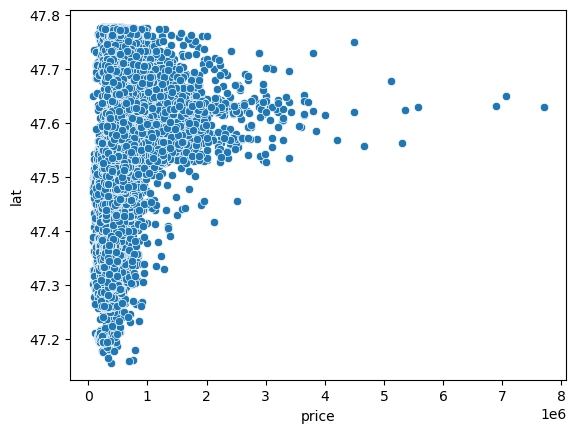

In [18]:
sns.scatterplot(x='price',y='lat',data=df)

<Axes: xlabel='long', ylabel='lat'>

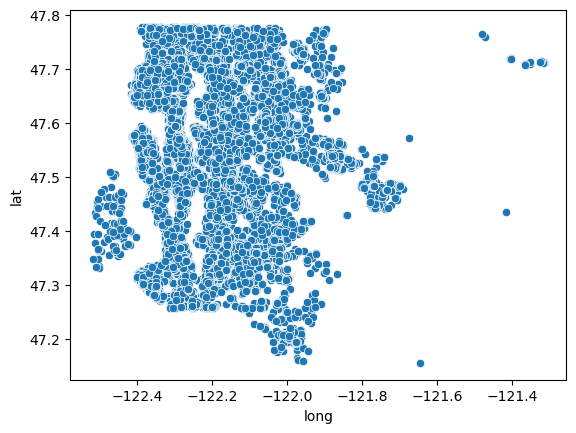

In [19]:
sns.scatterplot(x='long',y='lat',data=df)

In [25]:
non_top_1_perc=df.sort_values('price',ascending=False).iloc[216:]

<Axes: xlabel='price', ylabel='lat'>

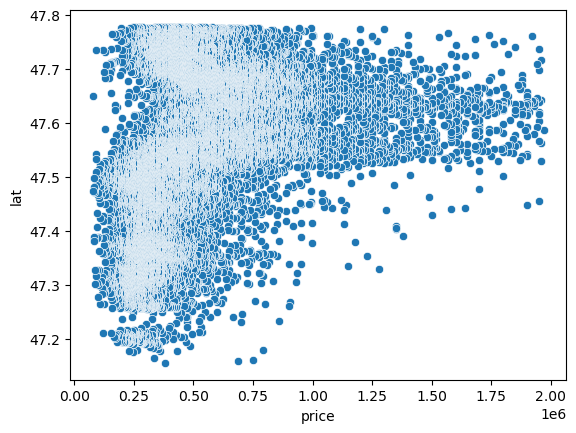

In [26]:
sns.scatterplot(x='price',y='lat',data=non_top_1_perc)

<Axes: xlabel='waterfront', ylabel='price'>

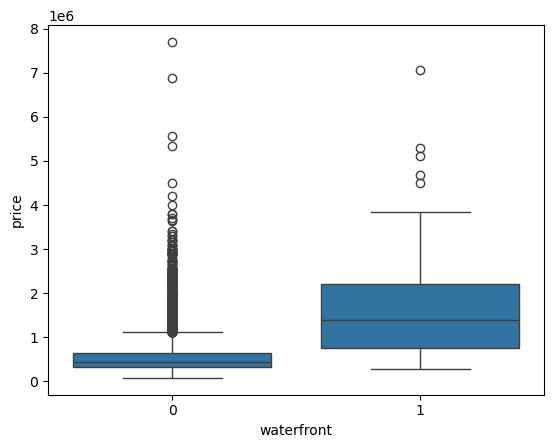

In [27]:
sns.boxplot(x='waterfront',y='price',data=df)

<Axes: xlabel='month', ylabel='price'>

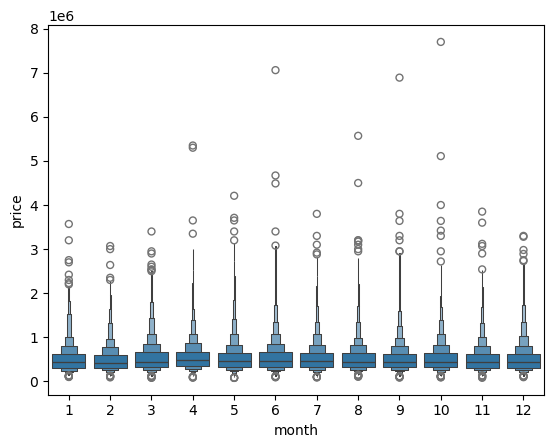

In [28]:
sns.boxenplot(x='month',y='price',data=df)

<Axes: xlabel='month'>

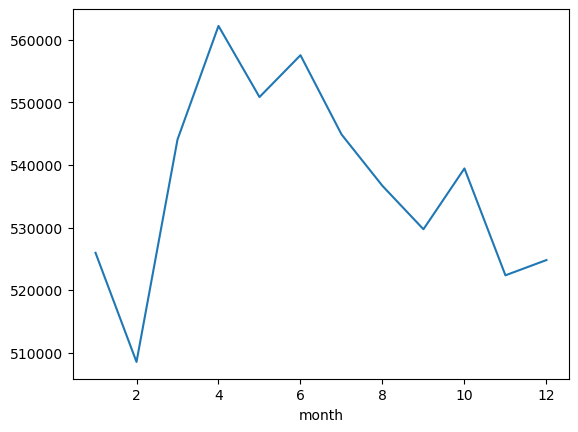

In [31]:
df.groupby('month').mean()['price'].plot()

In [32]:
df['yr_renovated'].value_counts()

yr_renovated
0       20683
2014       91
2013       37
2003       36
2005       35
        ...  
1948        1
1951        1
1959        1
1934        1
1944        1
Name: count, Length: 70, dtype: int64

In [33]:
df['sqft_basement'].value_counts()

sqft_basement
0       13110
600       221
700       218
500       214
800       206
        ...  
176         1
225         1
1275        1
274         1
248         1
Name: count, Length: 306, dtype: int64

In [72]:
X=non_top_1_perc.drop('price',axis=1).values

In [73]:
y=non_top_1_perc['price'].values

In [74]:
from sklearn.model_selection import train_test_split

In [75]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=101)

In [76]:
from sklearn.preprocessing import MinMaxScaler

In [77]:
scale=MinMaxScaler()

In [78]:
X_train=scale.fit_transform(X_train)

In [79]:
X_test=scale.transform(X_test)

In [80]:
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

In [81]:
model=Sequential()

In [82]:
model.add(Dense(19,activation='relu'))
model.add(Dense(19,activation='relu'))
model.add(Dense(19,activation='relu'))
model.add(Dense(19,activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam',loss='mse')

In [83]:
model.fit(x=X_train,y=y_train,validation_data=(X_test,y_test),batch_size=128,epochs=400)

Epoch 1/400
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 346868187136.0000 - val_loss: 356824481792.0000
Epoch 2/400
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 345579716608.0000 - val_loss: 352231030784.0000
Epoch 3/400
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 326663569408.0000 - val_loss: 306969575424.0000
Epoch 4/400
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 234550575104.0000 - val_loss: 160938901504.0000
Epoch 5/400
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 92821438464.0000 - val_loss: 59363926016.0000
Epoch 6/400
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 54404595712.0000 - val_loss: 54574370816.0000
Epoch 7/400
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 52964966400.0000 - val_loss: 53496451072.0000
Epoch 8/400
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 52025733120.0000 - val_loss: 52497375232.0000
Epoch 9/400
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 51055034368.0000 - val_loss: 51443695616.0000
Epoch 10/400
117/117 ━━━━━━━━

In [84]:
losses=pd.DataFrame(model.history.history)

In [85]:
losses

,loss,val_loss
0,3.468682e+11,3.568245e+11
1,3.455797e+11,3.522310e+11
2,3.266636e+11,3.069696e+11
3,2.345506e+11,1.609389e+11
4,9.282144e+10,5.936393e+10
...,...,...
395,2.033623e+10,2.055350e+10
396,2.032658e+10,2.054159e+10
397,2.034487e+10,2.051785e+10
398,2.030369e+10,2.051508e+10


In [86]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,explained_variance_score

In [87]:
predictions=model.predict(X_test)

201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step   


In [88]:
mean_absolute_error(y_test,predictions)

96241.9787814205

In [89]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15,year,month
count,2.159700e+04,21597.000000,21597.000000,21597.000000,2.159700e+04,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000
mean,5.402966e+05,3.373200,2.115826,2080.321850,1.509941e+04,1.494096,0.007547,0.234292,3.409825,7.657915,1788.596842,291.725008,1970.999676,84.464787,47.560093,-122.213982,1986.620318,12758.283512,2014.322962,6.573969
std,3.673681e+05,0.926299,0.768984,918.106125,4.141264e+04,0.539683,0.086549,0.766390,0.650546,1.173200,827.759761,442.667800,29.375234,401.821438,0.138552,0.140724,685.230472,27274.441950,0.467619,3.115061
min,7.800000e+04,1.000000,0.500000,370.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,3.000000,370.000000,0.000000,1900.000000,0.000000,47.155900,-122.519000,399.000000,651.000000,2014.000000,1.000000
25%,3.220000e+05,3.000000,1.750000,1430.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,47.471100,-122.328000,1490.000000,5100.000000,2014.000000,4.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,47.571800,-122.231000,1840.000000,7620.000000,2014.000000,6.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068500e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,47.678000,-122.125000,2360.000000,10083.000000,2015.000000,9.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,47.777600,-121.315000,6210.000000,871200.000000,2015.000000,12.000000


In [61]:
5.402966e+05


540296.6

In [90]:
explained_variance_score(y_test,predictions)

0.7510630406630131

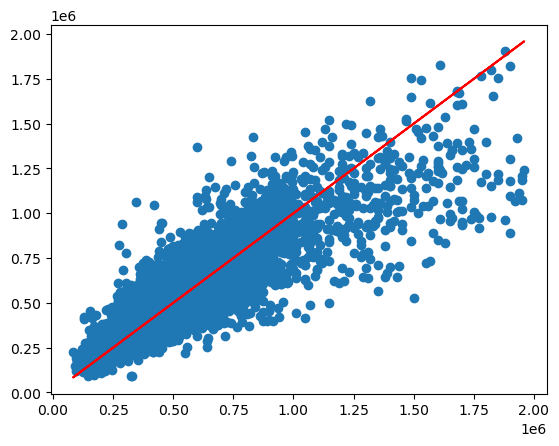

In [91]:
plt.scatter(y_test,predictions)
plt.plot(y_test,y_test,'r')

In [92]:
single_house=non_top_1_perc.drop('price',axis=1).iloc[0]

In [93]:
single_house

bedrooms             4.0000
bathrooms            3.5000
sqft_living       4370.0000
sqft_lot          8510.0000
floors               2.0000
waterfront           0.0000
view                 1.0000
condition            3.0000
grade               10.0000
sqft_above        3610.0000
sqft_basement      760.0000
yr_built          2003.0000
yr_renovated         0.0000
lat                 47.5876
long              -122.2040
sqft_living15     2960.0000
sqft_lot15       10347.0000
year              2014.0000
month                6.0000
Name: 6329, dtype: float64

In [94]:
single_house=scale.transform(single_house.values.reshape(-1,19))

In [95]:
model.predict(single_house)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


array([[1099714.2]], dtype=float32)

In [96]:
non_top_1_perc.head(1)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15,year,month
6329,1970000.0,4,3.5,4370,8510,2.0,0,1,3,10,3610,760,2003,0,47.5876,-122.204,2960,10347,2014,6
